In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as ans

print("Environment ready successfully!")

Environment ready successfully!


In [33]:
import pandas as pd

sales_df = pd.read_csv("../data/Raw_data/sales.csv")
stores_df = pd.read_csv("../data/Raw_data/stores.csv")
features_df = pd.read_csv("../data/Raw_data/features.csv")

print("sales data")
print(sales_df.head())

print("\nStores Data")
print(stores_df.head())

print("\nFeatures Data")
print(features_df.head())

sales data
   store_id  department        date  weekly_sales  is_holiday
0         1           1  2022-01-01     119075.96           1
1         1           2  2022-01-01     119107.85           1
2         1           3  2022-01-01      84369.88           1
3         1           4  2022-01-01      88445.24           1
4         1           5  2022-01-01      65159.85           1

Stores Data
   store_id store_type  store_size region
0         1          A      213810  North
1         2          C       31639   East
2         3          B      102098  South
3         4          B       88289  North
4         5          A      218696  North

Features Data
   store_id        date  temperature  fuel_price  markdown_1  markdown_2  \
0         1  2022-01-01        97.57        4.83    10334.49     5905.86   
1         1  2022-01-08        46.03        3.67     1356.75     2486.21   
2         1  2022-01-15        25.96        5.46     3861.22      596.15   
3         1  2022-01-22        25

In [34]:
print("SALES DATA INFO")
print(sales_df.info())

print("\nSALES DATA SHAPE")
print(sales_df.shape)

print("\nSALES DATA COLUMNS")
print(sales_df.columns)

print("\nSALES DATA DESCRIPTION")
print(sales_df.describe())

SALES DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156000 entries, 0 to 155999
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   store_id      156000 non-null  int64  
 1   department    156000 non-null  int64  
 2   date          156000 non-null  object 
 3   weekly_sales  156000 non-null  float64
 4   is_holiday    156000 non-null  int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 6.0+ MB
None

SALES DATA SHAPE
(156000, 5)

SALES DATA COLUMNS
Index(['store_id', 'department', 'date', 'weekly_sales', 'is_holiday'], dtype='object')

SALES DATA DESCRIPTION
            store_id   department   weekly_sales     is_holiday
count  156000.000000  156000.0000  156000.000000  156000.000000
mean       25.500000      10.5000   56503.488802       0.115385
std        14.430916       5.7663   46717.490663       0.319487
min         1.000000       1.0000     819.660000       0.000000
25%        13.000

In [35]:
print("MISSING VALUES IN SALES DATA")
print(sales_df.isnull().sum())


MISSING VALUES IN SALES DATA
store_id        0
department      0
date            0
weekly_sales    0
is_holiday      0
dtype: int64


In [36]:
sales_df['date'] = pd.to_datetime(sales_df['date'])

print(sales_df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156000 entries, 0 to 155999
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   store_id      156000 non-null  int64         
 1   department    156000 non-null  int64         
 2   date          156000 non-null  datetime64[ns]
 3   weekly_sales  156000 non-null  float64       
 4   is_holiday    156000 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3)
memory usage: 6.0 MB
None


In [37]:
print("DUPLICATE ROWS IN SALES DATA")
print(sales_df.duplicated().sum())

DUPLICATE ROWS IN SALES DATA
0


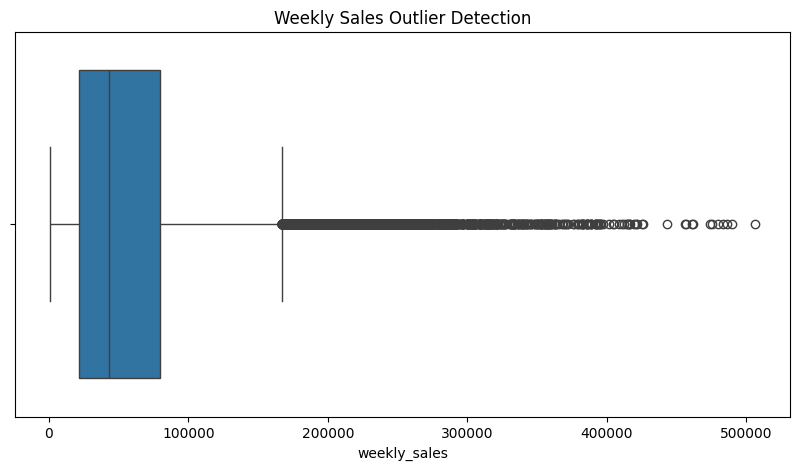

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.boxplot(x=sales_df['weekly_sales'])

plt.title("Weekly Sales Outlier Detection")

plt.show()


In [39]:
sales_df['year'] = sales_df['date'].dt.year
sales_df['month'] = sales_df['date'].dt.month
sales_df['day'] = sales_df['date'].dt.day

print(sales_df.head())

   store_id  department       date  weekly_sales  is_holiday  year  month  day
0         1           1 2022-01-01     119075.96           1  2022      1    1
1         1           2 2022-01-01     119107.85           1  2022      1    1
2         1           3 2022-01-01      84369.88           1  2022      1    1
3         1           4 2022-01-01      88445.24           1  2022      1    1
4         1           5 2022-01-01      65159.85           1  2022      1    1


In [40]:
print("FEATURES DATA INFO")
print(features_df.info())

print("\nMISSING VALUES IN FEATURES DATA")
print(features_df.isnull().sum())

FEATURES DATA INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7800 entries, 0 to 7799
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   store_id      7800 non-null   int64  
 1   date          7800 non-null   object 
 2   temperature   7800 non-null   float64
 3   fuel_price    7800 non-null   float64
 4   markdown_1    7800 non-null   float64
 5   markdown_2    7800 non-null   float64
 6   markdown_3    7800 non-null   float64
 7   markdown_4    7800 non-null   float64
 8   markdown_5    7800 non-null   float64
 9   cpi           7800 non-null   float64
 10  unemployment  7800 non-null   float64
 11  is_holiday    7800 non-null   int64  
 12  holiday_name  900 non-null    object 
 13  season        7800 non-null   object 
dtypes: float64(9), int64(2), object(3)
memory usage: 853.2+ KB
None

MISSING VALUES IN FEATURES DATA
store_id           0
date               0
temperature        0
fuel_price         0


In [41]:
features_df['holiday_name'] = features_df['holiday_name'].fillna('No Holiday')

print(features_df.isnull().sum())

store_id        0
date            0
temperature     0
fuel_price      0
markdown_1      0
markdown_2      0
markdown_3      0
markdown_4      0
markdown_5      0
cpi             0
unemployment    0
is_holiday      0
holiday_name    0
season          0
dtype: int64


In [42]:
features_df['date'] = pd.to_datetime(features_df['date'])

print(features_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7800 entries, 0 to 7799
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   store_id      7800 non-null   int64         
 1   date          7800 non-null   datetime64[ns]
 2   temperature   7800 non-null   float64       
 3   fuel_price    7800 non-null   float64       
 4   markdown_1    7800 non-null   float64       
 5   markdown_2    7800 non-null   float64       
 6   markdown_3    7800 non-null   float64       
 7   markdown_4    7800 non-null   float64       
 8   markdown_5    7800 non-null   float64       
 9   cpi           7800 non-null   float64       
 10  unemployment  7800 non-null   float64       
 11  is_holiday    7800 non-null   int64         
 12  holiday_name  7800 non-null   object        
 13  season        7800 non-null   object        
dtypes: datetime64[ns](1), float64(9), int64(2), object(2)
memory usage: 853.2+ KB
None


In [43]:
merged_df = pd.merge(
    sales_df,
    stores_df,
    on='store_id',
    how='left'
)

print(merged_df.head())

   store_id  department       date  weekly_sales  is_holiday  year  month  \
0         1           1 2022-01-01     119075.96           1  2022      1   
1         1           2 2022-01-01     119107.85           1  2022      1   
2         1           3 2022-01-01      84369.88           1  2022      1   
3         1           4 2022-01-01      88445.24           1  2022      1   
4         1           5 2022-01-01      65159.85           1  2022      1   

   day store_type  store_size region  
0    1          A      213810  North  
1    1          A      213810  North  
2    1          A      213810  North  
3    1          A      213810  North  
4    1          A      213810  North  


In [44]:
final_df = pd

In [45]:
final_df = pd.merge(
    merged_df,
    features_df,
    on=['store_id', 'date'],
    how='left'
)

print(final_df.head())

   store_id  department       date  weekly_sales  is_holiday_x  year  month  \
0         1           1 2022-01-01     119075.96             1  2022      1   
1         1           2 2022-01-01     119107.85             1  2022      1   
2         1           3 2022-01-01      84369.88             1  2022      1   
3         1           4 2022-01-01      88445.24             1  2022      1   
4         1           5 2022-01-01      65159.85             1  2022      1   

   day store_type  store_size  ... markdown_1  markdown_2  markdown_3  \
0    1          A      213810  ...   10334.49     5905.86     5261.52   
1    1          A      213810  ...   10334.49     5905.86     5261.52   
2    1          A      213810  ...   10334.49     5905.86     5261.52   
3    1          A      213810  ...   10334.49     5905.86     5261.52   
4    1          A      213810  ...   10334.49     5905.86     5261.52   

   markdown_4  markdown_5     cpi  unemployment  is_holiday_y  holiday_name  \
0     7

In [46]:
print(final_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156000 entries, 0 to 155999
Data columns (total 23 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   store_id      156000 non-null  int64         
 1   department    156000 non-null  int64         
 2   date          156000 non-null  datetime64[ns]
 3   weekly_sales  156000 non-null  float64       
 4   is_holiday_x  156000 non-null  int64         
 5   year          156000 non-null  int32         
 6   month         156000 non-null  int32         
 7   day           156000 non-null  int32         
 8   store_type    156000 non-null  object        
 9   store_size    156000 non-null  int64         
 10  region        156000 non-null  object        
 11  temperature   156000 non-null  float64       
 12  fuel_price    156000 non-null  float64       
 13  markdown_1    156000 non-null  float64       
 14  markdown_2    156000 non-null  float64       
 15  markdown_3    156

In [47]:
print(final_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156000 entries, 0 to 155999
Data columns (total 23 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   store_id      156000 non-null  int64         
 1   department    156000 non-null  int64         
 2   date          156000 non-null  datetime64[ns]
 3   weekly_sales  156000 non-null  float64       
 4   is_holiday_x  156000 non-null  int64         
 5   year          156000 non-null  int32         
 6   month         156000 non-null  int32         
 7   day           156000 non-null  int32         
 8   store_type    156000 non-null  object        
 9   store_size    156000 non-null  int64         
 10  region        156000 non-null  object        
 11  temperature   156000 non-null  float64       
 12  fuel_price    156000 non-null  float64       
 13  markdown_1    156000 non-null  float64       
 14  markdown_2    156000 non-null  float64       
 15  markdown_3    156

In [48]:
final_df.to_csv("../Data/Cleaned_Data/final_cleaned_dataset.csv", index=False)

print("Final cleaned dataset saved successfully!")

Final cleaned dataset saved successfully!
